# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [32]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import FakeData
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
from sklearn import metrics
import random
import numpy as np

In [33]:
seed = 1302
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True

torch.cuda.is_available()

True

In [34]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

batch_size = 1024

training_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
training_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True, num_workers=0)

test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

fake_set = FakeData(size=1000, image_size=(3, 32, 32), num_classes=10, transform=transform)
fake_loader = DataLoader(fake_set, batch_size=batch_size, shuffle=False, num_workers=0)

In [35]:
class NormalizeInverse(torchvision.transforms.Normalize):
    # Undoes the normalization and returns the reconstructed images in the input domain.
    def __init__(self, mean, std):
        mean = torch.tensor(mean)
        std = torch.tensor(std)
        std_inv = 1.0 / (std + 1.0e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean_inv, std_inv)

    def __call__(self, tensor):
        return super().__call__(tensor.clone())
    
inv_normalize = NormalizeInverse(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1920932e-07..0.9137256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.827451].


Batch of images shape: torch.Size([1024, 3, 32, 32])
Batch of labels shape: torch.Size([1024])


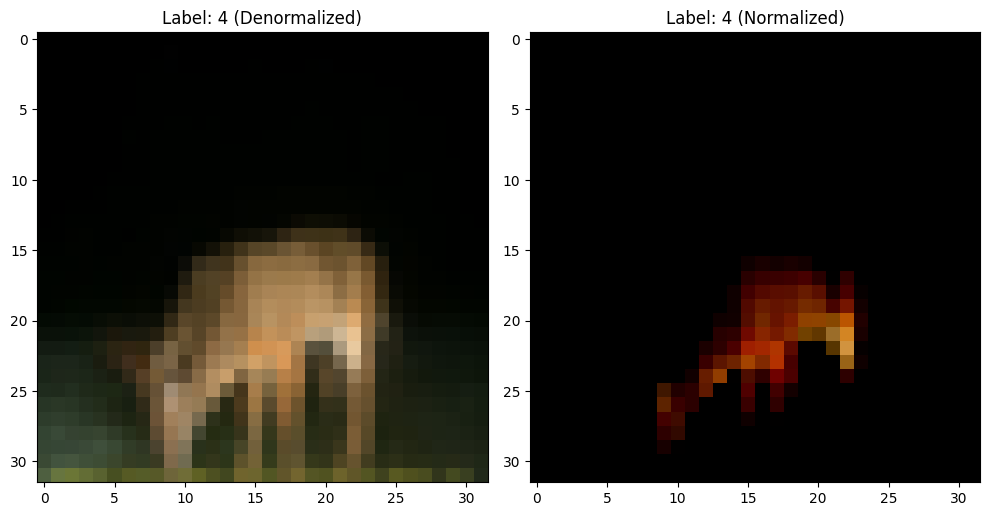

In [36]:
for images, labels in training_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(inv_normalize(images[0, :]).permute(1, 2, 0))
    axes[1].imshow(images[0, :].permute(1, 2, 0))
    axes[0].set_title(f"Label: {labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break

class_dict = {class_name:id_class for id_class, class_name in enumerate(training_set.classes)}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1920932e-07..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Batch of images shape: torch.Size([1000, 3, 32, 32])
Batch of labels shape: torch.Size([1000])


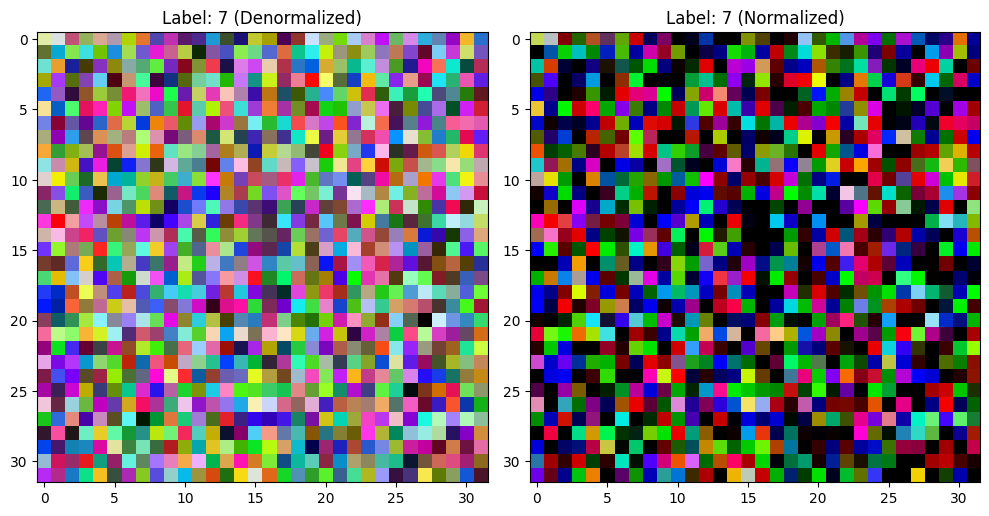

In [37]:
for images, labels in fake_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(inv_normalize(images[0, :]).permute(1, 2, 0))
    axes[1].imshow(images[0, :].permute(1, 2, 0))
    axes[0].set_title(f"Label: {labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break

In [38]:
print(class_dict)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [39]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=2, padding=1)

        self.flatten_dim = 512 * 8 * 8
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = torch.flatten(x, 1) # (batch_size, 512, 8, 8) -> (batch_size, 512*8*8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 30

In [41]:
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for i, (images, labels) in enumerate(training_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(training_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_train_loss:.4f}")

Epoch [1/30], Loss: 1.8310
Epoch [2/30], Loss: 1.4071
Epoch [3/30], Loss: 1.1932
Epoch [4/30], Loss: 1.0198
Epoch [5/30], Loss: 0.8636
Epoch [6/30], Loss: 0.7053
Epoch [7/30], Loss: 0.5446
Epoch [8/30], Loss: 0.3588
Epoch [9/30], Loss: 0.2021
Epoch [10/30], Loss: 0.1230
Epoch [11/30], Loss: 0.0757
Epoch [12/30], Loss: 0.0486
Epoch [13/30], Loss: 0.0449
Epoch [14/30], Loss: 0.0387
Epoch [15/30], Loss: 0.0362
Epoch [16/30], Loss: 0.0331
Epoch [17/30], Loss: 0.0226
Epoch [18/30], Loss: 0.0240
Epoch [19/30], Loss: 0.0187
Epoch [20/30], Loss: 0.0168
Epoch [21/30], Loss: 0.0195
Epoch [22/30], Loss: 0.0226
Epoch [23/30], Loss: 0.0129
Epoch [24/30], Loss: 0.0099
Epoch [25/30], Loss: 0.0127
Epoch [26/30], Loss: 0.0198
Epoch [27/30], Loss: 0.0187
Epoch [28/30], Loss: 0.0169
Epoch [29/30], Loss: 0.0202
Epoch [30/30], Loss: 0.0359


Test Accuracy: 68.970%


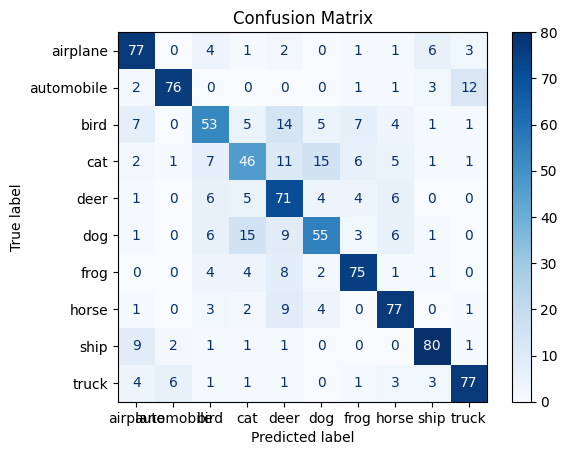

In [42]:
model.eval()
y_gt, y_pred = [], []
with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_gt.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_gt = torch.tensor(y_gt)
y_pred = torch.tensor(y_pred)

accuracy = metrics.accuracy_score(y_gt, y_pred)
print(f'Test Accuracy: {100* accuracy:.3f}%')

conf_matrix = metrics.confusion_matrix(y_gt, y_pred)
conf_matrix = conf_matrix.astype(np.float32) 
conf_matrix /= conf_matrix.sum(axis=1, keepdims=True)
conf_matrix = (100 * conf_matrix).astype(np.int32)

display_ = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=test_set.classes)
display_.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [43]:
print(f'Per class accuracy: {np.diag(conf_matrix).mean():.3f}%')

Per class accuracy: 68.700%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].


Batch of images shape: torch.Size([1024, 3, 32, 32])
Batch of labels shape: torch.Size([1024])


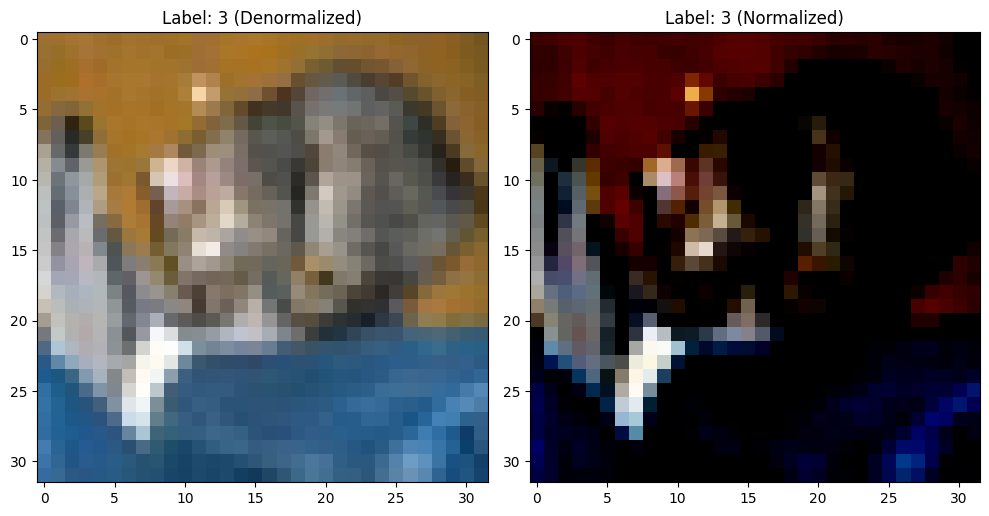

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Batch of images shape: torch.Size([1000, 3, 32, 32])
Batch of labels shape: torch.Size([1000])


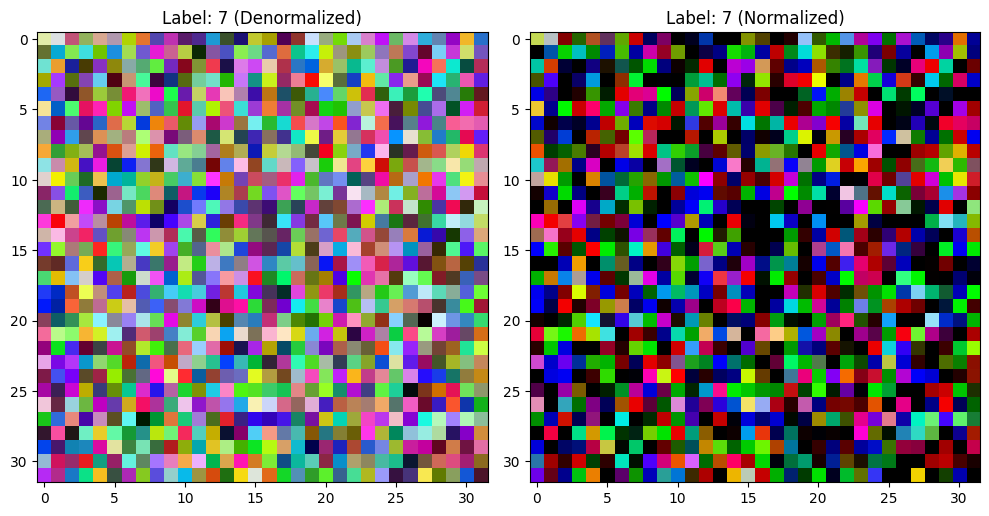

In [44]:
for images, labels in test_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(images[0, :].permute(1, 2, 0) * torch.tensor([0.5, 0.5, 0.5]) + torch.tensor([0.5, 0.5, 0.5]))
    axes[1].imshow(images[0, :].permute(1, 2, 0))
    axes[0].set_title(f"Label: {labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break


for fake_images, fake_labels in fake_loader:
    print(f"Batch of images shape: {fake_images.shape}")
    print(f"Batch of labels shape: {fake_labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(fake_images[0, :].permute(1, 2, 0) * torch.tensor([0.5, 0.5, 0.5]) + torch.tensor([0.5, 0.5, 0.5]))
    axes[1].imshow(fake_images[0, :].permute(1, 2, 0))
    axes[0].set_title(f"Label: {fake_labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {fake_labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break

In [45]:
def plot_logits_and_softmax(model, images, labels, device, k, temperature, test_set=None):
    outputs = model(images.to(device))
    pred = outputs[k].detach().cpu()
    pred_max = pred.argmax().item()
    if test_set is not None:
        print(f'GT: {test_set.classes[labels[k]]}, Pred: {test_set.classes[pred_max]}') # La label corrispondente

    fig, ax = plt.subplots(1, 3, figsize=(15, 7))

    ax[0].bar(np.arange(10), pred)
    ax[0].set_title('Logit')
    ax[1].bar(np.arange(10), F.softmax(pred / temperature, dim=0).detach().cpu())
    ax[1].set_title(f'Softmax with Temperature = {temperature}')
    ax[2].imshow((images[k, :] * 0.5 + 0.5).permute(1, 2, 0))
    ax[2].set_title('Input Image')
    plt.show()

Original Image with Logits and Softmax
GT: bird, Pred: dog


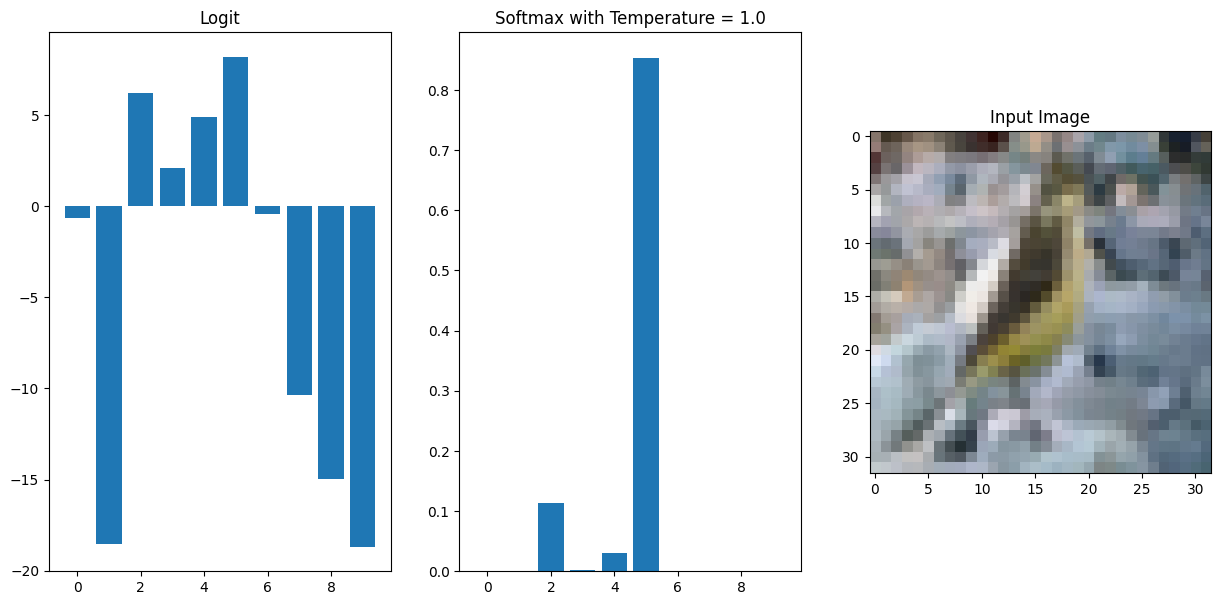

Fake Image with Logits and Softmax


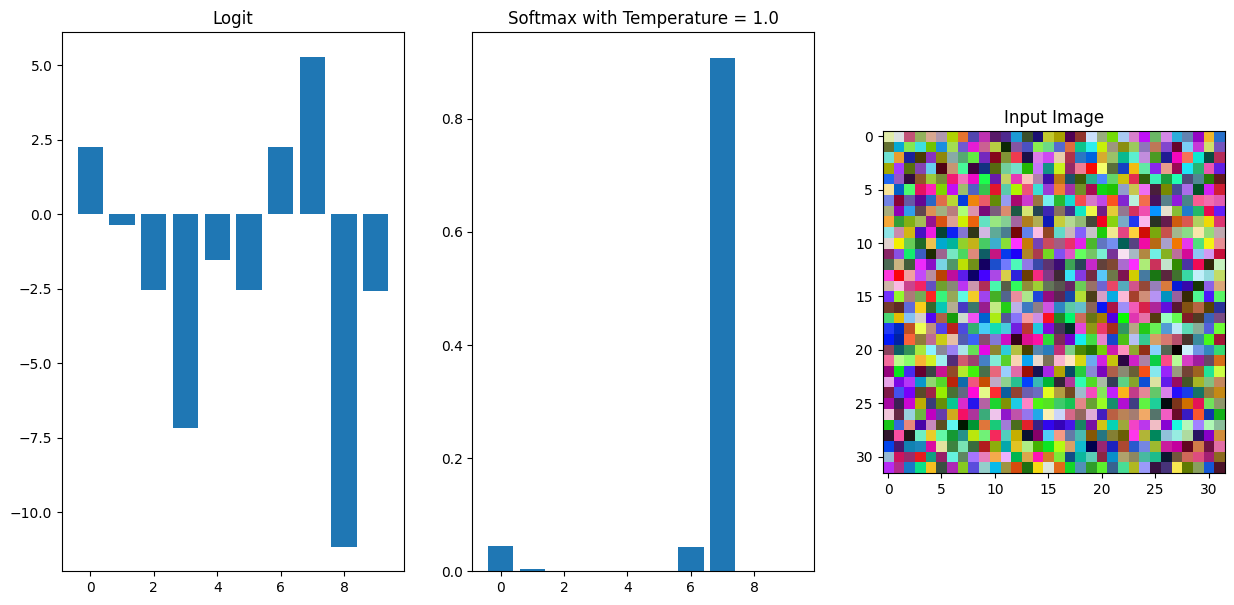

In [46]:
print('Original Image with Logits and Softmax')
plot_logits_and_softmax(model, images, labels, device, k=random.randint(0, images.shape[0] - 1), temperature=1.0, test_set=test_set)

print('Fake Image with Logits and Softmax')
plot_logits_and_softmax(model, fake_images, fake_labels, device, k=0, temperature=1.0)
        

In [47]:
def max_logit(logit):
    return logit.max(dim=1)[0]

def max_softmax(logit, temperature=1):
    return F.softmax(logit / temperature, dim=1).max(dim=1)[0]

def compute_scores(dataloader, score_function):
    scores = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            batch_scores = score_function(outputs)
            scores.extend(batch_scores.cpu().numpy())
    return torch.tensor(scores)

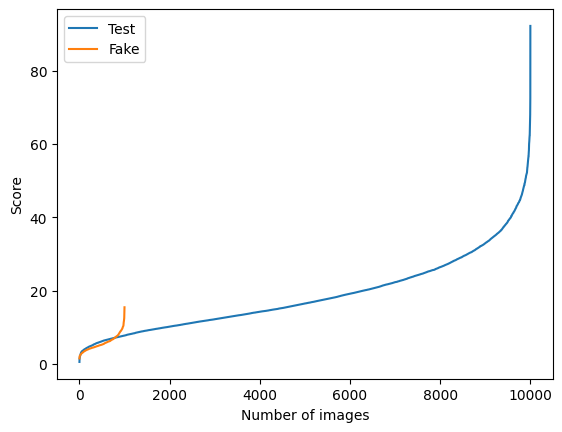

In [48]:
scores_test = compute_scores(test_loader, max_logit)
scores_fake = compute_scores(fake_loader, max_logit)

plt.plot(sorted(scores_test.cpu()), label='Test')
plt.plot(sorted(scores_fake.cpu()), label='Fake')
plt.legend()
plt.xlabel('Number of images')
plt.ylabel('Score')
plt.show()

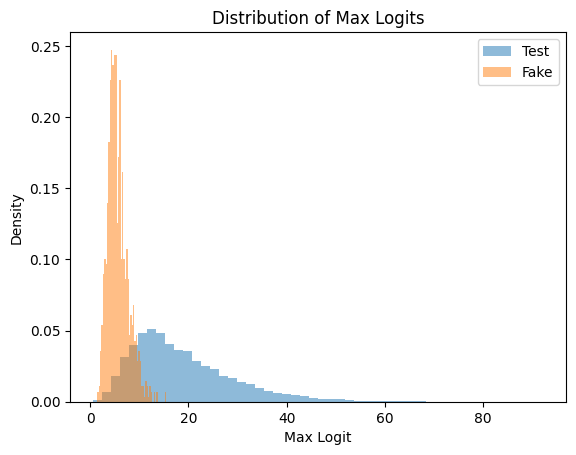

In [49]:
plt.hist(scores_test.cpu(), density=True, bins=50, alpha=0.5, label='Test')
plt.hist(scores_fake.cpu(), density=True, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.xlabel('Max Logit')
plt.ylabel('Density')
plt.title('Distribution of Max Logits')
plt.show()

In [50]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=48, out_channels=24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=24, out_channels=12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=12, out_channels=3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [51]:
autoencoder = Autoencoder().to(device)

mse_loss = nn.MSELoss()
optimizer_ae = optim.Adam(autoencoder.parameters(), lr=0.0001)

In [52]:
epochs = 20
for epoch in range(epochs):
    autoencoder.train()
    train_loss = 0.0
    for i, (images, labels) in enumerate(training_loader):
        images = images.to(device)

        optimizer_ae.zero_grad()
        _, outputs = autoencoder(images)
        loss = mse_loss(outputs, images)
        loss.backward()
        optimizer_ae.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(training_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_train_loss:.4f}")

Epoch [1/20], Loss: 0.2504
Epoch [2/20], Loss: 0.2146
Epoch [3/20], Loss: 0.1441
Epoch [4/20], Loss: 0.1112
Epoch [5/20], Loss: 0.0972
Epoch [6/20], Loss: 0.0857
Epoch [7/20], Loss: 0.0773
Epoch [8/20], Loss: 0.0718
Epoch [9/20], Loss: 0.0681
Epoch [10/20], Loss: 0.0654
Epoch [11/20], Loss: 0.0633
Epoch [12/20], Loss: 0.0616
Epoch [13/20], Loss: 0.0600
Epoch [14/20], Loss: 0.0587
Epoch [15/20], Loss: 0.0574
Epoch [16/20], Loss: 0.0561
Epoch [17/20], Loss: 0.0549
Epoch [18/20], Loss: 0.0536
Epoch [19/20], Loss: 0.0522
Epoch [20/20], Loss: 0.0506


In [53]:
autoencoder.eval()
val_loss = nn.MSELoss(reduction='none')

scores_fake_ae = []

with torch.no_grad():
    for images, labels in fake_loader:
        images = images.to(device)
        _, outputs = autoencoder(images)
        batch_loss = val_loss(outputs, images).mean(dim=[1, 2, 3])
        scores_fake_ae.extend(-batch_loss.cpu().numpy())
scores_fake_ae = torch.tensor(scores_fake_ae)

scores_test_ae = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, outputs = autoencoder(images)
        batch_loss = val_loss(outputs, images).mean(dim=[1, 2, 3])
        scores_test_ae.extend(-batch_loss.cpu().numpy())

scores_test_ae = torch.tensor(scores_test_ae)

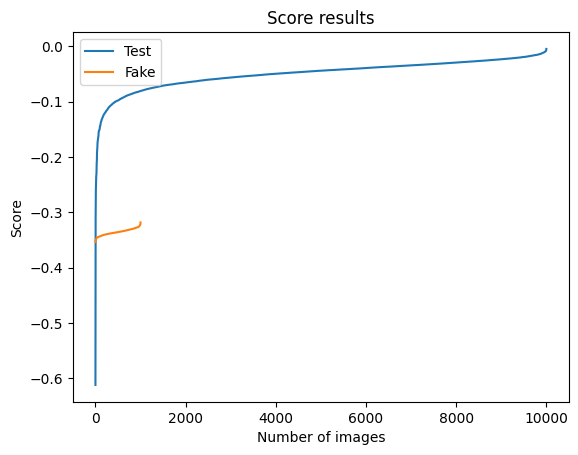

In [54]:
plt.plot(sorted(scores_test_ae.cpu()), label='Test')
plt.plot(sorted(scores_fake_ae.cpu()), label='Fake')
plt.title('Score results')
plt.legend()
plt.xlabel('Number of images')
plt.ylabel('Score')
plt.show()

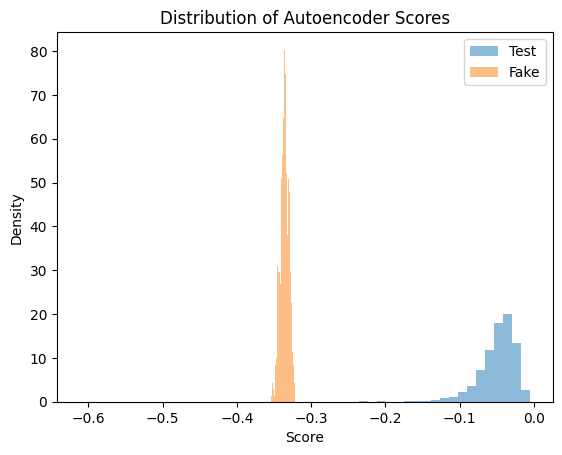

In [55]:
plt.hist(scores_test_ae.cpu(), density=True, bins=50, alpha=0.5, label='Test')
plt.hist(scores_fake_ae.cpu(), density=True, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.title('Distribution of Autoencoder Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.show()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


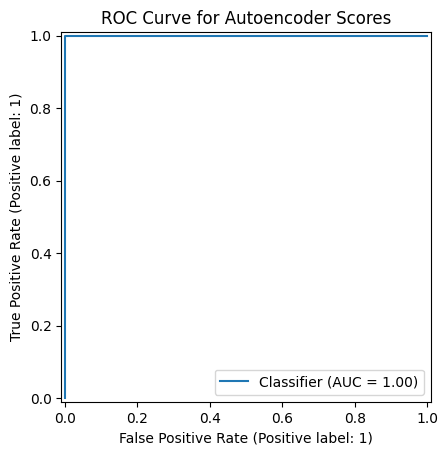

In [56]:
ypred = torch.cat((scores_test_ae, scores_fake_ae))
ytest = torch.ones_like(scores_test_ae)
yfake = torch.zeros_like(scores_fake_ae)

y = torch.cat((ytest, yfake))
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())
plt.title('ROC Curve for Autoencoder Scores')
plt.show()

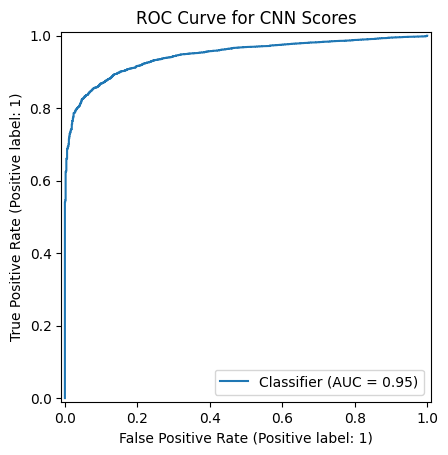

In [57]:
ypred = torch.cat((scores_test, scores_fake))
ytest = torch.ones_like(scores_test)
yfake = torch.zeros_like(scores_fake)

y = torch.cat((ytest, yfake))
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())
plt.title('ROC Curve for CNN Scores')
plt.show()

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [58]:
for i, c in enumerate(test_set.classes):
    print(i, c)

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05098028..1.0000001].


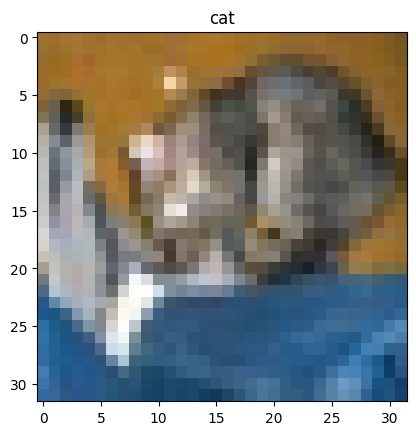

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12156853..1.0000001].


Classifier is already wrong or target label same as GT, skipping attack!
Classifier is already wrong or target label same as GT, skipping attack!


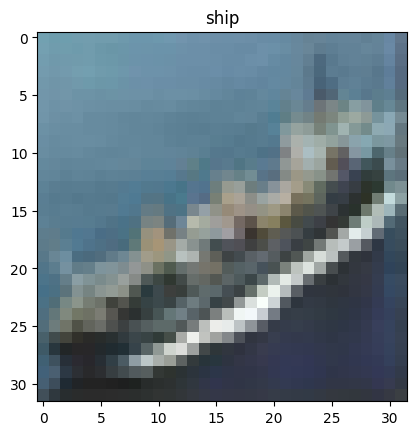

Attack started!
Untargeted attack success! Budget:12/255
Attack started!
Untargeted attack success! Budget:2/255


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07843127..1.0000001].


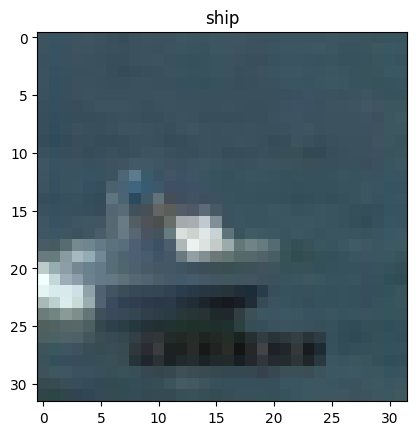

Attack started!
Untargeted attack success! Budget:2/255
Attack started!
Untargeted attack success! Budget:7/255


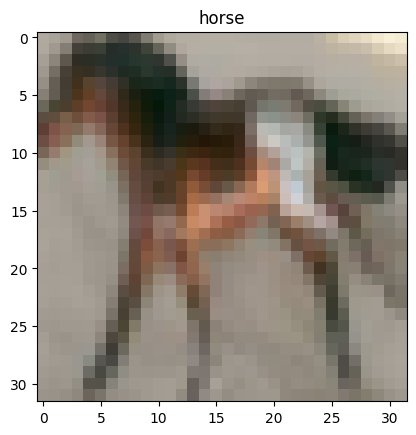

Attack started!
Untargeted attack success! Budget:2/255
Attack started!
Untargeted attack success! Budget:1/255


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023529297..1.0000001].


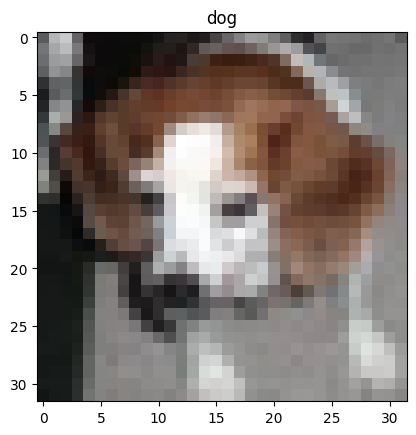

Attack started!
Untargeted attack success! Budget:4/255
Classifier is already wrong or target label same as GT, skipping attack!


In [59]:
loss = nn.CrossEntropyLoss()
model.eval()
for i, (images, labels) in enumerate(test_loader):
    targeted_attack = False
    target_label = class_dict['cat']
    eps = 1.0/255.0
    sample_id = 0

    image, label = images[sample_id].to(device), labels[sample_id].to(device)
    
    image = image.unsqueeze(0)
    label = label.unsqueeze(0)

    image.requires_grad_(True)
    
    output = model(image)

    if i%2 == 0:
        img = inv_normalize(image[0])
        plt.imshow(img.permute(1, 2, 0).detach().cpu())
        plt.title(test_set.classes[output.argmax().item()])
        plt.show()

    if output.argmax().item() != label.item() or label.item() == target_label:
        print('Classifier is already wrong or target label same as GT, skipping attack!')
    else:
        done = False
        print('Attack started!')
        n = 0

        if targeted_attack:
            target = torch.tensor(target_label).unsqueeze(0).to(device)
            print(f'Target:{test_set.classes[target.squeeze().item()]}')

        while not done:
            output = model(image)
            yt = target if targeted_attack else label
            l = loss(output, yt)
            grad = torch.autograd.grad(l, image)[0] #dl/d(image)
            step = -eps if targeted_attack else eps
            image = (image + step * grad.sign()).clamp(-1, 1).detach().requires_grad_(True)
            n += 1

            with torch.no_grad():
                output = model(image)
                pred = output.argmax().item()


            if not targeted_attack and pred != label.item():
                print(f'Untargeted attack success! Budget:{int(255*n*eps)}/255')
                done = True

            elif targeted_attack and pred == target_label:
                print(f'Targeted attack {test_set.classes[pred]} success! Budget:{int(255*n*eps)}/255')
                done = True



In [60]:
#plt.imshow(255*diff.cpu().detach().squeeze().mean(0))
#plt.colorbar()

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [61]:
num_epochs = 30
eps = 5.0/255.0

optimizer = optim.AdamW(model.parameters(), lr=0.0001)

In [62]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for i, (images, labels) in enumerate(training_loader):
        images, labels = images.to(device), labels.to(device)
        images.requires_grad_(True)
        output = model(images)

        loss = F.cross_entropy(output, labels)
        grad = torch.autograd.grad(loss, images)[0] #dl/d(images)
        adv_images = (images + eps * grad.sign()).clamp(-1, 1).detach().requires_grad_(True)

        optimizer.zero_grad()
        output = model(adv_images)
        loss = F.cross_entropy(output, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(training_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}")

Epoch [1/30], Loss: 1.4112
Epoch [2/30], Loss: 0.7507
Epoch [3/30], Loss: 0.6133
Epoch [4/30], Loss: 0.5196
Epoch [5/30], Loss: 0.4400
Epoch [6/30], Loss: 0.3692
Epoch [7/30], Loss: 0.3033
Epoch [8/30], Loss: 0.2438
Epoch [9/30], Loss: 0.1917
Epoch [10/30], Loss: 0.1468
Epoch [11/30], Loss: 0.1078
Epoch [12/30], Loss: 0.0790
Epoch [13/30], Loss: 0.0557
Epoch [14/30], Loss: 0.0388
Epoch [15/30], Loss: 0.0267
Epoch [16/30], Loss: 0.0184
Epoch [17/30], Loss: 0.0135
Epoch [18/30], Loss: 0.0091
Epoch [19/30], Loss: 0.0063
Epoch [20/30], Loss: 0.0046
Epoch [21/30], Loss: 0.0033
Epoch [22/30], Loss: 0.0024
Epoch [23/30], Loss: 0.0018
Epoch [24/30], Loss: 0.0014
Epoch [25/30], Loss: 0.0011
Epoch [26/30], Loss: 0.0009
Epoch [27/30], Loss: 0.0007
Epoch [28/30], Loss: 0.0006
Epoch [29/30], Loss: 0.0005
Epoch [30/30], Loss: 0.0004


In [64]:
model.eval()
val_loss = 0.0
y_gt, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)

        l = F.cross_entropy(output, labels)
        val_loss += l.item()

        y_gt.append(labels.cpu())
        y_pred.append(output.argmax(dim=1).cpu())
    
avg_val_loss = val_loss / len(test_loader)
print(f"Validation Loss: {avg_val_loss:.4f}")

Validation Loss: 4.1481


Test Accuracy: 70.860%


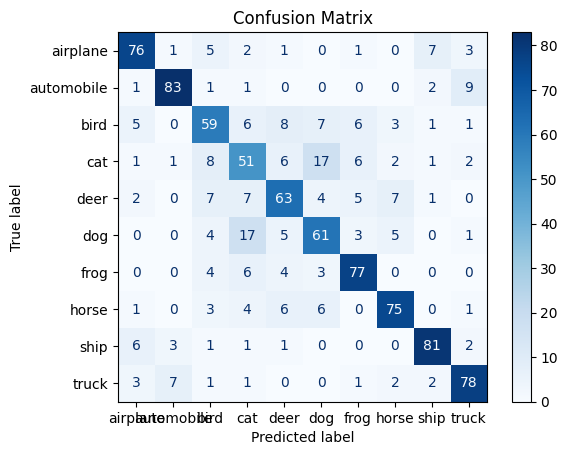

In [65]:
y_pred_tensor = torch.cat(y_pred)
y_gt_tensor = torch.cat(y_gt)

acc = sum(y_pred_tensor == y_gt_tensor) / len(y_gt_tensor)
print(f'Test Accuracy: {100* acc:.3f}%')

cmat = metrics.confusion_matrix(y_gt_tensor, y_pred_tensor)
cmat = cmat.astype(np.float32)
cmat /= cmat.sum(axis=1, keepdims=True)
cmat = (100 * cmat).astype(np.int32)
display_ = metrics.ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=test_set.classes)
display_.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [66]:
print('Per class accuracy: {:.3f}%'.format(np.diag(cmat).mean()))

Per class accuracy: 70.400%


### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.


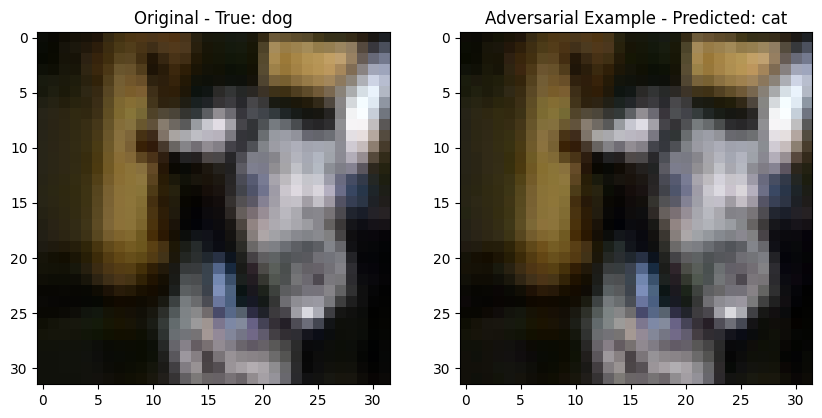

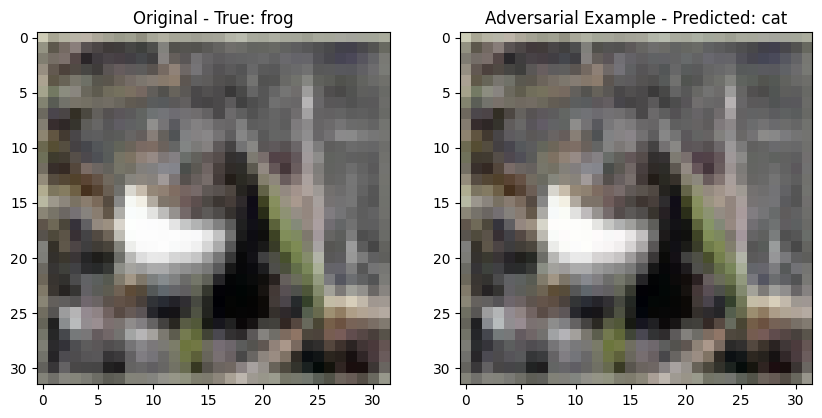

Success Rate: 13.67%


In [83]:
model.eval()
target_class = class_dict['cat']
adv_examples = []
eps = 3.0/255.0
count, total = 0, 0

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    mask = (labels != target_class)
    if mask.sum() == 0:
        continue

    images, labels = images[mask], labels[mask]
    y_target = torch.full_like(labels, target_class)
    images.requires_grad_(True)

    output = model(images)
    l = F.cross_entropy(output, y_target)
    grad = torch.autograd.grad(l, images)[0]
    adv_images = (images - eps * grad.sign()).clamp(-1, 1).detach()

    with torch.no_grad():
        output = model(adv_images)
        pred = output.argmax(dim=1)
        count += (pred == target_class).sum().item()

        if pred[0] == target_class:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            img = inv_normalize(images[0])
            adv_img = inv_normalize(adv_images[0])
            ax[0].imshow(img.permute(1, 2, 0).cpu().clamp(0, 1))
            ax[0].set_title(f'Original - True: {test_set.classes[labels[0].item()]}')
            ax[1].imshow(adv_img.permute(1, 2, 0).cpu().clamp(0, 1))
            ax[1].set_title(f'Adversarial Example - Predicted: {test_set.classes[pred[0].item()]}')
            plt.show()

        total += len(labels)

    adv_examples.extend(adv_images.detach().cpu())
print(f'Success Rate: {count/total*100:.2f}%')
    